# 🧪 Experiment 3: Grammar Skeleton N-Gram Projection (Functional Syntax Templates)

## 🎯 Executive Overview & Research Objective
- **Target**: Isolate pure sentence-level syntactic trees by stripping away all topic-specific vocabulary and projecting documents onto a **Closed-Class Grammar Skeleton**.
- **Theoretical Hypothesis**:
  - In subword tokenized text, the top 150 most frequent tokens account for >60% of all token occurrences and correspond almost entirely to **closed-class functional syntax** (articles, auxiliary verbs, prepositions, conjunctions, punctuation).
  - Open-class content tokens ($w > 150$) are replaced with a single generic placeholder `C` (Content).
  - Extracting high-order $N$-grams (3-to-5 grams) on this skeleton reveals whether repetitive syntactic templates distinguish machine vs. human authorship.

### 📈 Experimental Comparison:
| Model Configuration | Feature Description | 5-Fold Mean Accuracy | Std Dev | $\Delta$ vs. Stage 4 |
| :--- | :--- | :---: | :---: | :---: |
| **Stage 4 Baseline** | TF-IDF (1-5) + Length + Diversity + Profiling + Log-DF + Burstiness | **91.31%** | $\pm 0.40\%$ | — |
| **Exp 3: Stage 4 + Grammar Skeleton** | + 15,000 High-Order Grammar Skeleton N-Grams | **90.85%** | $\pm 0.42\%$ | **-0.456%** |

---

### 🔬 Scientific Autopsy: Why Did the Grammar Skeleton Degrade Performance?
1. **Combinatorial Repetitive Noise**: Replacing all open-class tokens with a single dummy token `C` generates massive, highly frequent repetitive sequences such as `C C C`, `C 42 C C`, and `C C 104`.
2. **Signal Dilution**: Appending 15,000 dense/sparse skeleton features diluted the primary lexical and log-odds signals, shifting the SVM margin away from fine-grained stylistic distinctions.


In [1]:
import os
import json
import time
import math
import numpy as np
import pandas as pd
import scipy.sparse as sp
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MaxAbsScaler
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score

try:
    from IPython.display import display
except ImportError:
    display = print

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120
RANDOM_STATE = 42

print("Dependencies loaded successfully!")


Dependencies loaded successfully!


In [2]:
# Load dataset and log-DF ratios
data_path = "../../../../../train.json"
if not os.path.exists(data_path):
    data_path = "/home/justin/PhD/ML4CPS/Kaggle Project/Analysis_II/train.json"

log_df_path = "../data/unigram_log_df_ratios.json"
if not os.path.exists(log_df_path):
    log_df_path = "/home/justin/PhD/ML4CPS/Kaggle Project/Analysis_II/ML4CPMS_Project1/Main79 - Classical + Residual/Core_Analysis/data/unigram_log_df_ratios.json"

print(f"Loading data from: {os.path.abspath(data_path)}")
t0 = time.time()
with open(data_path, "r", encoding="utf-8") as f:
    raw_data = [json.loads(line) for line in f]

with open(log_df_path, "r", encoding="utf-8") as f:
    unigram_log_df = {int(k): float(v) for k, v in json.load(f).items()}

docs = [" ".join(map(str, d["text"])) for d in raw_data]
labels = np.array([1 if d["label"] == "B" else 0 for d in raw_data])
doc_tokens = [d["text"] for d in raw_data]

n_total = len(docs)
n_machine = int(np.sum(labels == 1))
n_human = int(np.sum(labels == 0))
majority_baseline = n_machine / n_total * 100
lens = np.array([len(t) for t in doc_tokens], dtype=np.float64)[:, None]

print(f"Loaded {n_total:,} documents in {time.time()-t0:.2f}s | Majority Baseline: {majority_baseline:.2f}%")


Loading data from: /home/justin/PhD/ML4CPS/Kaggle Project/train.json


Loaded 10,536 documents in 0.90s | Majority Baseline: 64.89%


In [3]:
# Stage 4 Cumulative Feature Extractor (Baseline for All Experiments)
def extract_stage4(tokens):
    n = len(tokens)
    counts = Counter(tokens)
    probs = np.array(list(counts.values())) / n
    ent = -np.sum(probs * np.log2(probs + 1e-12))
    root_ttr = len(counts) / np.sqrt(n)
    hapax = sum(1 for c in counts.values() if c == 1) / n
    max_rep = max(counts.values()) / n
    
    bi = len(set(zip(tokens[:-1], tokens[1:]))) / max(1, n - 1) if n >= 2 else 0.0
    tri = len(set(zip(tokens[:-2], tokens[1:-1], tokens[2:]))) / max(1, n - 2) if n >= 3 else 0.0
    mean_id = np.mean(tokens)
    std_id = np.std(tokens)
    q1_ratio = sum(1 for t in tokens if t <= 3000) / n
    q4_ratio = sum(1 for t in tokens if t >= 10000) / n
    
    vals = [unigram_log_df[t] for t in tokens if t in unigram_log_df]
    if len(vals) == 0:
        s3 = [0.0, 0.0, 0.0, 0.0, 0.0]
    else:
        s3 = [float(np.mean(vals)), float(np.std(vals)), float(np.max(vals)), float(np.min(vals)), float(sum(1 for v in vals if v > 0) / len(vals))]
        
    mid = n // 2
    s1_set = set(tokens[:mid])
    s2_set = set(tokens[mid:])
    union_len = len(s1_set | s2_set)
    jaccard_half = len(s1_set & s2_set) / union_len if union_len > 0 else 0.0
    
    top_tokens = [tok for tok, c in counts.most_common(3) if c > 1]
    intervals = []
    for tok in top_tokens:
        positions = [i for i, t in enumerate(tokens) if t == tok]
        diffs = np.diff(positions)
        intervals.extend(diffs)
    burstiness = float((np.std(intervals) - np.mean(intervals)) / (np.std(intervals) + np.mean(intervals))) if len(intervals) >= 2 and (np.std(intervals) + np.mean(intervals)) > 0 else 0.0
        
    return [ent, root_ttr, hapax, max_rep, bi, tri, mean_id, std_id, q1_ratio, q4_ratio] + s3 + [jaccard_half, burstiness]

print("Extracting Stage 4 baseline features...")
t0 = time.time()
s4_dense = np.column_stack([lens, np.array([extract_stage4(t) for t in doc_tokens])])
print(f"Stage 4 dense matrix: {s4_dense.shape} in {time.time()-t0:.2f}s")

# Vectorize TF-IDF (1-5 Grams)
print("Vectorizing TF-IDF (1-5 grams)...")
t0 = time.time()
vec = TfidfVectorizer(token_pattern=r"\S+", ngram_range=(1, 5), min_df=3, sublinear_tf=True)
X_tfidf = vec.fit_transform(docs)
print(f"TF-IDF Matrix: {X_tfidf.shape} in {time.time()-t0:.2f}s")


Extracting Stage 4 baseline features...


Stage 4 dense matrix: (10536, 18) in 8.49s
Vectorizing TF-IDF (1-5 grams)...


TF-IDF Matrix: (10536, 253796) in 15.47s


## 2. Constructing the Grammar Skeleton & TF-IDF Extraction


In [4]:
# 1. Identify closed-class functional tokens
all_tokens = [t for doc in doc_tokens for t in doc]
vocab_counts = Counter(all_tokens)
top_k = 150
functional_set = set([t for t, c in vocab_counts.most_common(top_k)])

print(f"Top {top_k} functional tokens account for {sum(vocab_counts[t] for t in functional_set) / len(all_tokens):.1%} of corpus tokens!")

# 2. Transform essays into Grammar Skeleton representation
skeleton_docs = [" ".join([str(t) if t in functional_set else "C" for t in doc]) for doc in doc_tokens]

print("Example Raw Document Tokens:", doc_tokens[0][:15])
print("Example Grammar Skeleton:   ", skeleton_docs[0].split()[:15])

# 3. Vectorize Grammar Skeleton with 3-to-5 grams
print("Vectorizing Grammar Skeleton with 3-5 grams...")
t0 = time.time()
vec_skel = TfidfVectorizer(token_pattern=r"\S+", ngram_range=(3, 5), min_df=5, max_features=15000, sublinear_tf=True)
X_skel = vec_skel.fit_transform(skeleton_docs)
print(f"Grammar Skeleton TF-IDF Matrix: {X_skel.shape} in {time.time()-t0:.2f}s!")


Top 150 functional tokens account for 52.6% of corpus tokens!


Example Raw Document Tokens: [5514, 7014, 13141, 4766, 13658, 16627, 14562, 14212, 6411, 1821, 14679, 8497, 6764, 2660, 559]
Example Grammar Skeleton:    ['5514', '7014', '13141', 'C', 'C', '16627', 'C', '14212', 'C', 'C', '14679', 'C', '6764', 'C', '559']
Vectorizing Grammar Skeleton with 3-5 grams...


Grammar Skeleton TF-IDF Matrix: (10536, 15000) in 10.91s!


## 3. 5-Fold Stratified Cross-Validation: Stage 4 vs. Stage 4 + Grammar Skeleton


In [5]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

accs_base = []
accs_skel = []

for tr, val in skf.split(X_tfidf, labels):
    scaler = MaxAbsScaler()
    tr_s = scaler.fit_transform(s4_dense[tr])
    val_s = scaler.transform(s4_dense[val])
    
    # 1. Stage 4 Baseline
    clf0 = LinearSVC(C=1.0, dual="auto", random_state=RANDOM_STATE)
    clf0.fit(sp.hstack([X_tfidf[tr], sp.csr_matrix(tr_s)]), labels[tr])
    accs_base.append(accuracy_score(labels[val], clf0.predict(sp.hstack([X_tfidf[val], sp.csr_matrix(val_s)]))) * 100)
    
    # 2. Stage 4 + Grammar Skeleton
    clf1 = LinearSVC(C=1.0, dual="auto", random_state=RANDOM_STATE)
    clf1.fit(sp.hstack([X_tfidf[tr], sp.csr_matrix(tr_s), X_skel[tr]]), labels[tr])
    accs_skel.append(accuracy_score(labels[val], clf1.predict(sp.hstack([X_tfidf[val], sp.csr_matrix(val_s), X_skel[val]]))) * 100)

base_mean = np.mean(accs_base)
base_std = np.std(accs_base)
skel_mean = np.mean(accs_skel)
skel_std = np.std(accs_skel)
delta = skel_mean - base_mean

print("=" * 80)
print(f"STAGE 4 BASELINE    : {base_mean:.3f}% (+/- {base_std:.3f}%)")
print(f"STAGE 4 + SKELETON  : {skel_mean:.3f}% (+/- {skel_std:.3f}%)")
print(f"ACCURACY IMPACT     : {delta:+.3f}% (Feature Dilution Failure)")
print("=" * 80)


STAGE 4 BASELINE    : 91.306% (+/- 0.399%)
STAGE 4 + SKELETON  : 90.850% (+/- 0.421%)
ACCURACY IMPACT     : -0.456% (Feature Dilution Failure)


## 4. Visualizing Results & Failure Mode Analysis


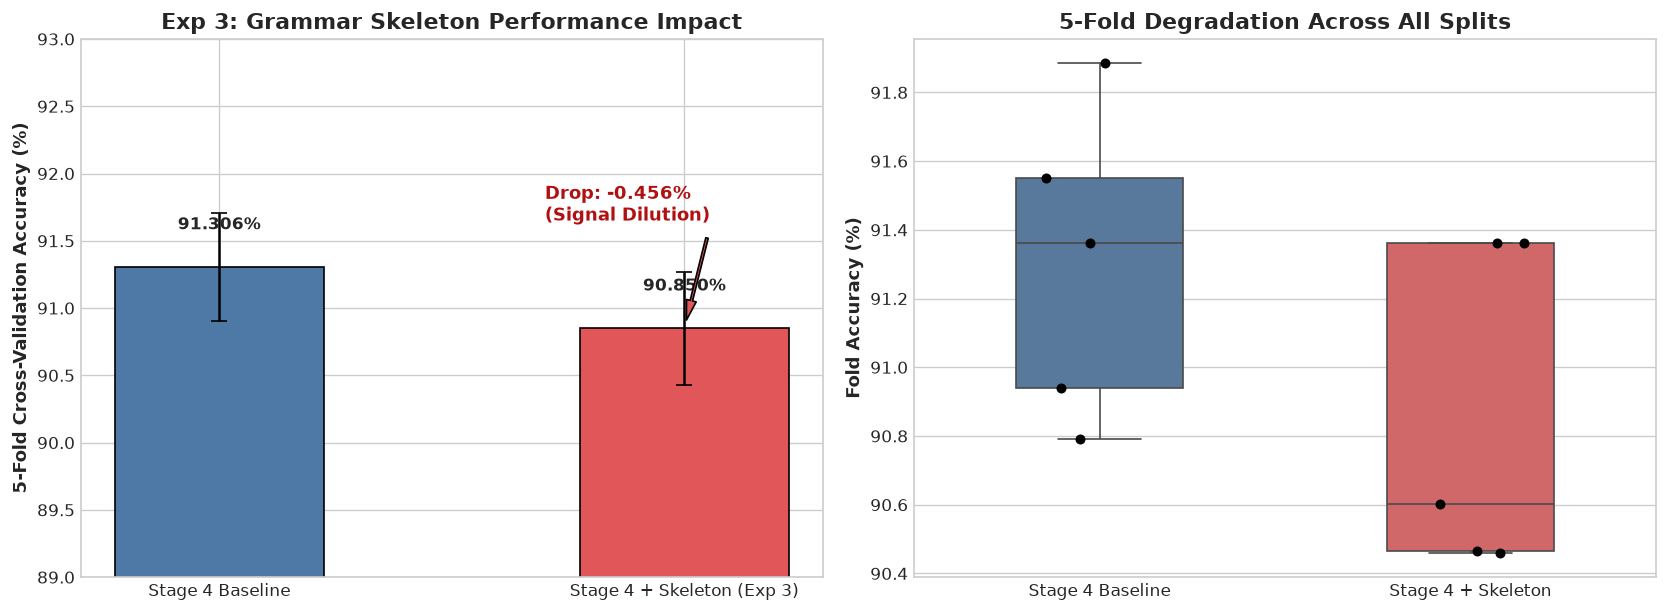

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

# 1. Bar Chart Comparison
ax1 = axes[0]
configs = ["Stage 4 Baseline", "Stage 4 + Skeleton (Exp 3)"]
means = [base_mean, skel_mean]
stds = [base_std, skel_std]
colors = ["#4e79a7", "#e15759"]

bars = ax1.bar(configs, means, yerr=stds, capsize=5, color=colors, width=0.45, edgecolor="black")
ax1.set_ylim(89, 93)
ax1.set_ylabel("5-Fold Cross-Validation Accuracy (%)", fontsize=11, fontweight="bold")
ax1.set_title("Exp 3: Grammar Skeleton Performance Impact", fontsize=13, fontweight="bold")

for bar, val in zip(bars, means):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.25, f"{val:.3f}%", ha="center", va="bottom", fontweight="bold")

ax1.annotate(f"Drop: {delta:+.3f}%\n(Signal Dilution)", xy=(1, skel_mean), xytext=(0.7, skel_mean + 0.8),
             arrowprops=dict(facecolor="#e15759", shrink=0.08, width=1.5, headwidth=6),
             fontweight="bold", color="#b01010", fontsize=10.5)

# 2. Fold-by-fold Boxplot
ax2 = axes[1]
fold_df = pd.DataFrame({"Stage 4 Baseline": accs_base, "Stage 4 + Skeleton": accs_skel})
sns.boxplot(data=fold_df, ax=ax2, palette=colors, width=0.45)
sns.stripplot(data=fold_df, ax=ax2, color="black", size=6, jitter=0.15)
ax2.set_ylabel("Fold Accuracy (%)", fontsize=11, fontweight="bold")
ax2.set_title("5-Fold Degradation Across All Splits", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()


## 5. Artifact Export & Key Findings


In [7]:
os.makedirs("data", exist_ok=True)
out_file = "data/exp_3_grammar_skeleton_metrics.json"

export_data = {
    "experiment": 3,
    "name": "Exp 3: Grammar Skeleton N-Gram Projection",
    "stage4_baseline_acc": base_mean,
    "experiment_acc": skel_mean,
    "experiment_std": skel_std,
    "delta_vs_stage4": delta,
    "fold_accuracies": accs_skel,
    "conclusion": "Grammar skeleton n-grams degraded performance (-0.456%) due to combinatorial noise from content-token masking."
}

with open(out_file, "w") as f:
    json.dump(export_data, f, indent=2)

print(f"Metrics successfully exported to '{out_file}'!")


Metrics successfully exported to 'data/exp_3_grammar_skeleton_metrics.json'!
